# **Histogram**

In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.

## Objectives

In this lab, you will perform the following:

- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.

## Demo: Working with database

#### Download the database file.

In [1]:
import urllib.request

# Database URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite"

# Download database
urllib.request.urlretrieve(
    url,
    "survey-data.sqlite"
)

print("Database downloaded successfully.")

Database downloaded successfully.


#### Install the required libraries and import them

In [2]:
#!pip install pandas

In [3]:
#!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database

In [5]:
# Connect to SQLite database
conn = sqlite3.connect("survey-data.sqlite")

print("Connected successfully.")

Connected successfully.


## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**

In [6]:
# SQL query to count total rows in the table

query = """
SELECT COUNT(*) AS total_rows
FROM main
"""

# Execute query
result = pd.read_sql_query(query, conn)

# Display result
print(result)

   total_rows
0       65437


**Demo 2: List all tables**

In [7]:
# SQL query to list all tables in the database

query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

# Execute query
tables = pd.read_sql_query(query, conn)

# Display table names
print(tables)

   name
0  main


**Demo 3: Group data by age**

In [8]:
# SQL query to group respondents by Age

query = """
SELECT Age,
       COUNT(*) AS Respondent_Count
FROM main
GROUP BY Age
ORDER BY Respondent_Count DESC
"""

# Execute query
age_group_df = pd.read_sql_query(query, conn)

# Display results
print(age_group_df)

                  Age  Respondent_Count
0     25-34 years old             23911
1     35-44 years old             14942
2     18-24 years old             14098
3     45-54 years old              6249
4     55-64 years old              2575
5  Under 18 years old              2568
6   65 years or older               772
7   Prefer not to say               322


## Visualizing Data with Histograms

### 1. Visualizing the distribution of data (Histograms)

**1.1 Histogram of `CompTotal` (Total Compensation)**

Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.

In [9]:
# SQL query to fetch CompTotal values

query = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

comp_df = pd.read_sql_query(query, conn)

# Display first few rows
print(comp_df.head())

   CompTotal
0  2040000.0
1    28000.0
2    85000.0
3    50000.0
4   110000.0


In [11]:
# Remove extreme outliers using 99th percentile

upper_limit = comp_df['CompTotal'].quantile(0.99)

filtered_comp = comp_df[
    comp_df['CompTotal'] <= upper_limit
]

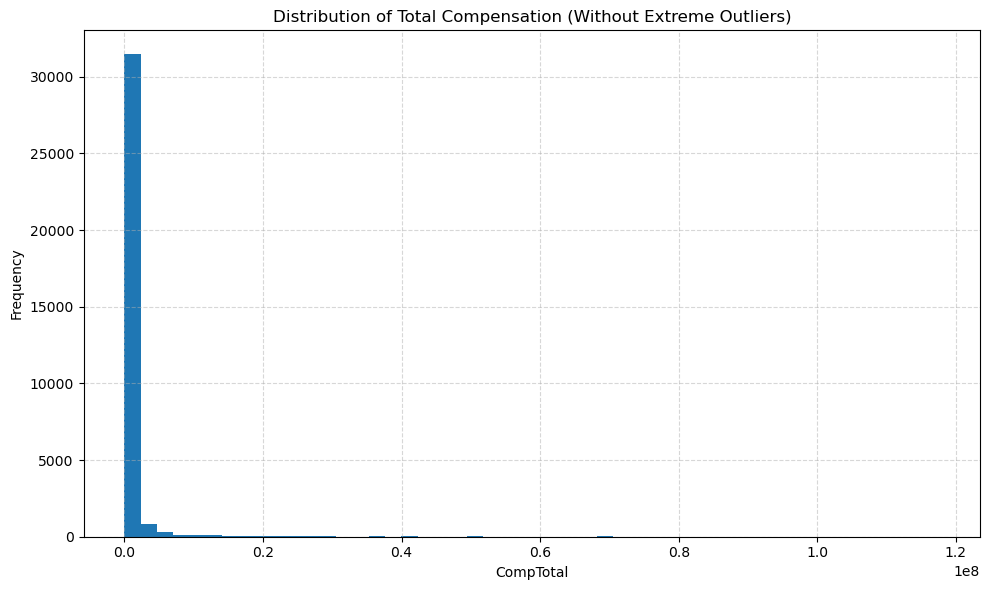

In [12]:
# Improved histogram

plt.figure(figsize=(10,6))

plt.hist(
    filtered_comp['CompTotal'],
    bins=50
)

plt.title('Distribution of Total Compensation (Without Extreme Outliers)')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

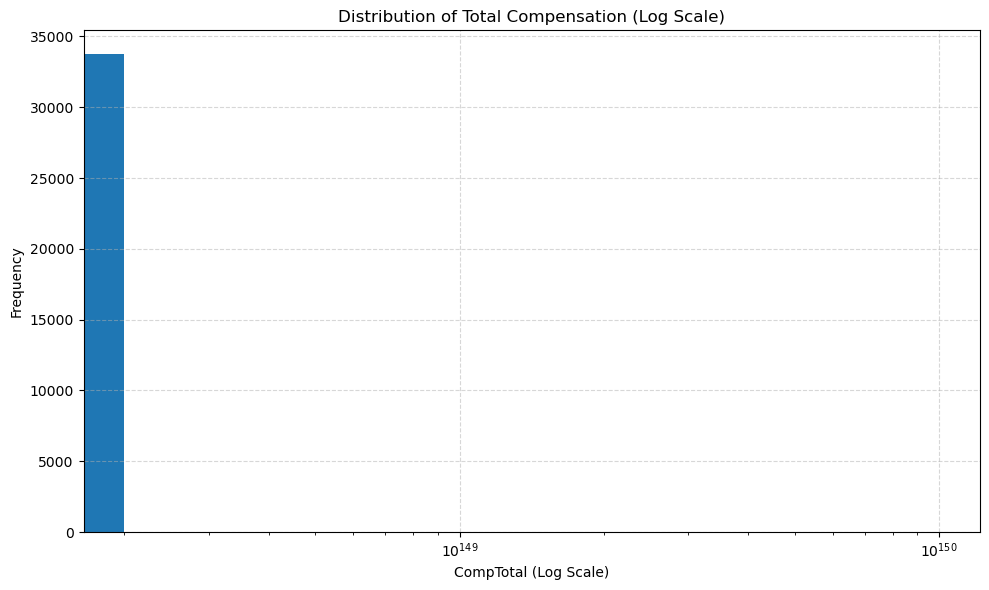

In [13]:
# Histogram with log scale

plt.figure(figsize=(10,6))

plt.hist(
    comp_df['CompTotal'],
    bins=50
)

plt.xscale('log')

plt.title('Distribution of Total Compensation (Log Scale)')
plt.xlabel('CompTotal (Log Scale)')
plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**

Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.

In [14]:
# SQL query to fetch YearsCodePro values

query = """
SELECT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL
"""

years_df = pd.read_sql_query(query, conn)

# Display first few rows
print(years_df.head())

  YearsCodePro
0           17
1           27
2            7
3           11
4           25


In [15]:
# Convert YearsCodePro to numeric

years_df['YearsCodePro'] = pd.to_numeric(
    years_df['YearsCodePro'],
    errors='coerce'
)

# Remove missing values after conversion
years_df = years_df.dropna()

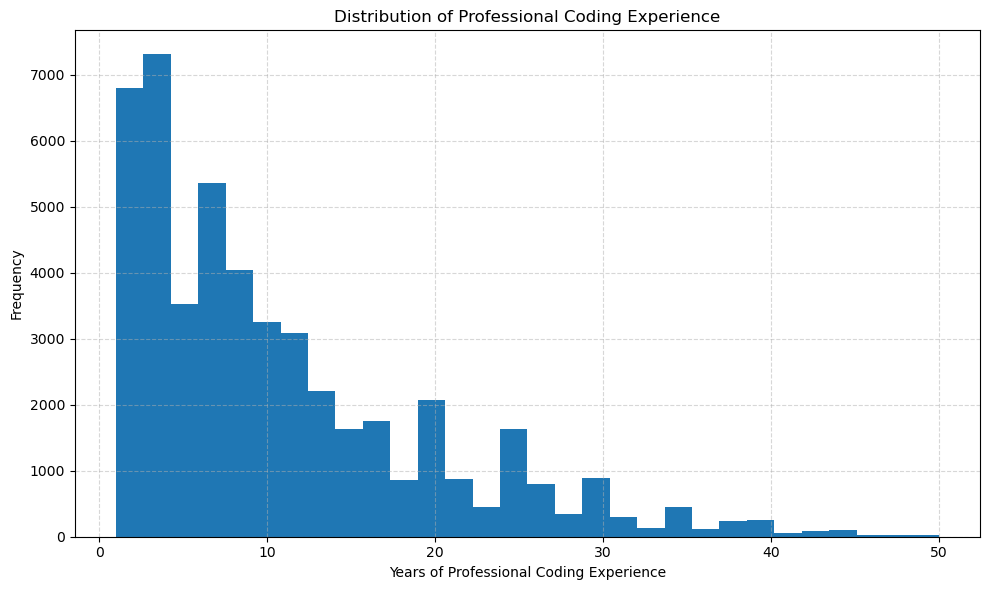

In [16]:
# Plot histogram

plt.figure(figsize=(10,6))

plt.hist(
    years_df['YearsCodePro'],
    bins=30
)

plt.title('Distribution of Professional Coding Experience')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Frequency')

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2. Visualizing Relationships in Data

**2.1 Histogram Comparison of `CompTotal` by `Age` Group**

Objective: Use histograms to compare the distribution of CompTotal across different Age groups.

In [17]:
# SQL query to fetch Age and CompTotal

query = """
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL
  AND Age IS NOT NULL
"""

age_comp_df = pd.read_sql_query(query, conn)

# Display first few rows
print(age_comp_df.head())

               Age  CompTotal
0  18-24 years old  2040000.0
1  25-34 years old    28000.0
2  35-44 years old    85000.0
3  35-44 years old    50000.0
4  25-34 years old   110000.0


In [18]:
# Remove extreme outliers using 99th percentile

upper_limit = age_comp_df['CompTotal'].quantile(0.99)

filtered_df = age_comp_df[
    age_comp_df['CompTotal'] <= upper_limit
]

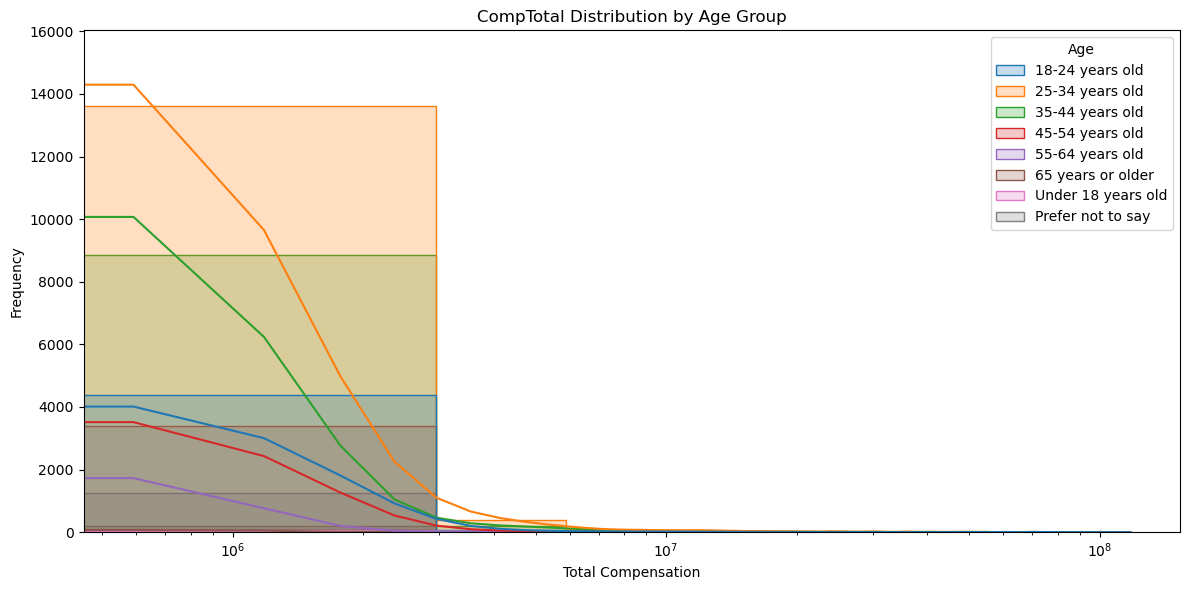

In [20]:
# Create histogram comparison by Age group
import seaborn as sns
plt.figure(figsize=(12,6))

sns.histplot(
    data=filtered_df,
    x='CompTotal',
    hue='Age',
    bins=40,
    kde=True,
    element='step'
)

plt.title('CompTotal Distribution by Age Group')
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')

plt.xscale('log')   # Better visualization for compensation data

plt.tight_layout()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**

Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.

In [21]:
# SQL query to fetch Age and TimeSearching

query = """
SELECT Age, TimeSearching
FROM main
WHERE Age IS NOT NULL
  AND TimeSearching IS NOT NULL
"""

time_df = pd.read_sql_query(query, conn)

# Display first few rows
print(time_df.head())

               Age               TimeSearching
0  35-44 years old         30-60 minutes a day
1  35-44 years old         30-60 minutes a day
2  45-54 years old        60-120 minutes a day
3  25-34 years old         15-30 minutes a day
4  25-34 years old  Less than 15 minutes a day


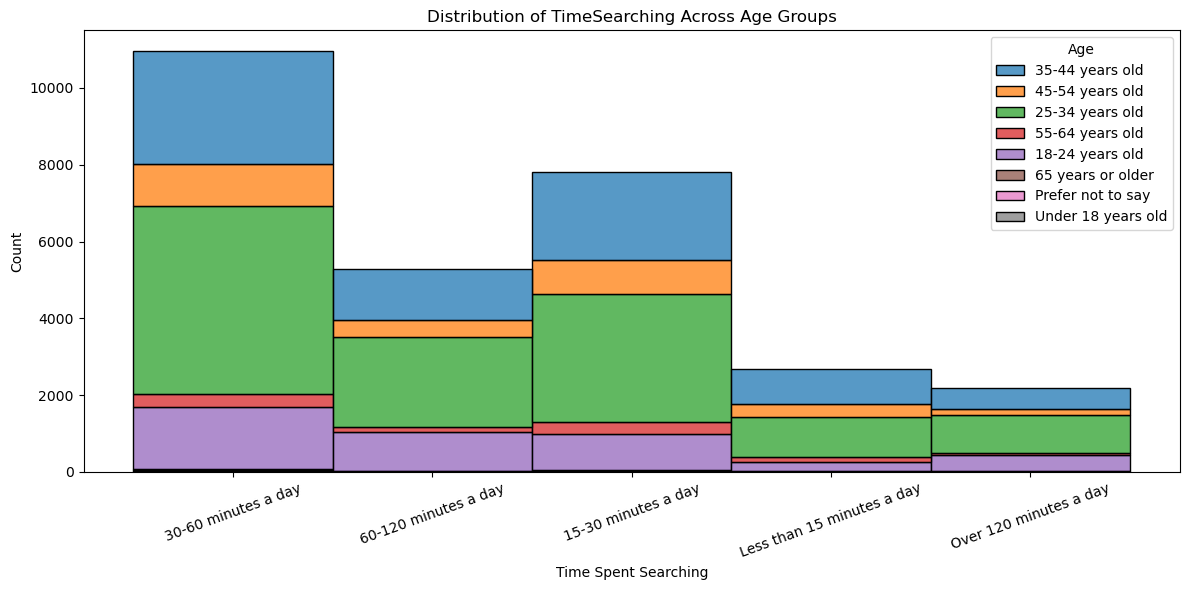

In [22]:
# Create histogram comparison by Age group

plt.figure(figsize=(12,6))

sns.histplot(
    data=time_df,
    x='TimeSearching',
    hue='Age',
    multiple='stack'
)

plt.title('Distribution of TimeSearching Across Age Groups')
plt.xlabel('Time Spent Searching')
plt.ylabel('Count')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data

**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**

Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.

In [23]:
# SQL query to fetch DatabaseWantToWorkWith column

query = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""

db_df = pd.read_sql_query(query, conn)

# Display first few rows
print(db_df.head())

       DatabaseWantToWorkWith
0                  PostgreSQL
1  Firebase Realtime Database
2    MongoDB;MySQL;PostgreSQL
3           PostgreSQL;SQLite
4             Cloud Firestore


In [24]:
# Split multiple databases and flatten into one list

all_databases = []

for item in db_df['DatabaseWantToWorkWith']:
    databases = item.split(';')
    all_databases.extend(databases)

# Convert into Series and count frequencies
database_counts = pd.Series(all_databases).value_counts().head(5)

print(database_counts)

PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


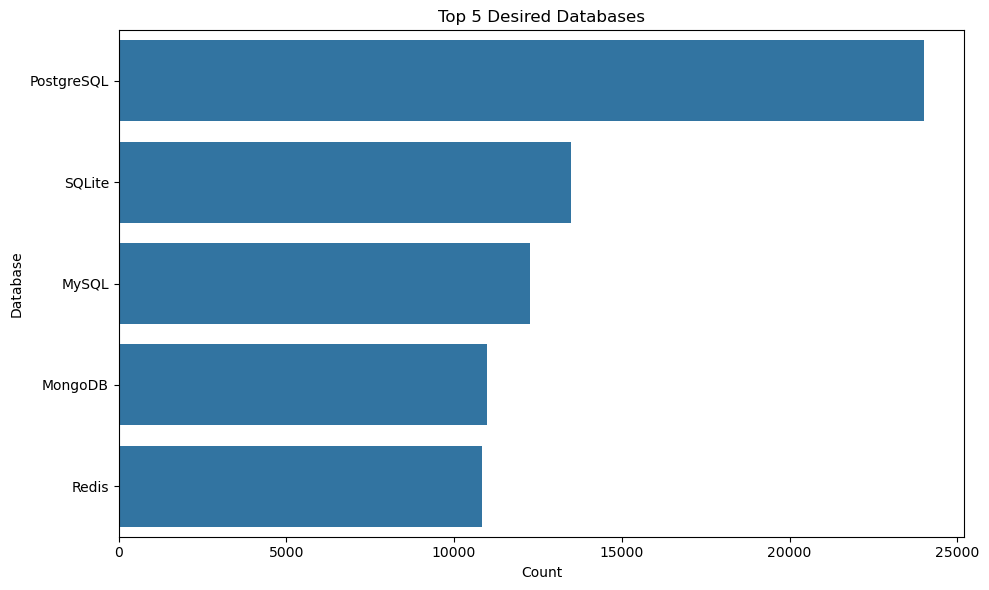

In [25]:
# Plot histogram/bar chart of top 5 desired databases

plt.figure(figsize=(10,6))

sns.barplot(
    x=database_counts.values,
    y=database_counts.index
)

plt.title('Top 5 Desired Databases')
plt.xlabel('Count')
plt.ylabel('Database')

plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**

Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).

In [26]:
# SQL query to fetch RemoteWork data

query = """
SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL
"""

remote_df = pd.read_sql_query(query, conn)

# Display first few rows
print(remote_df.head())

  RemoteWork
0     Remote
1     Remote
2     Remote
3     Remote
4  In-person


In [27]:
# Count preferred work arrangements

remote_counts = (
    remote_df['RemoteWork']
    .value_counts()
)

print(remote_counts)

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64


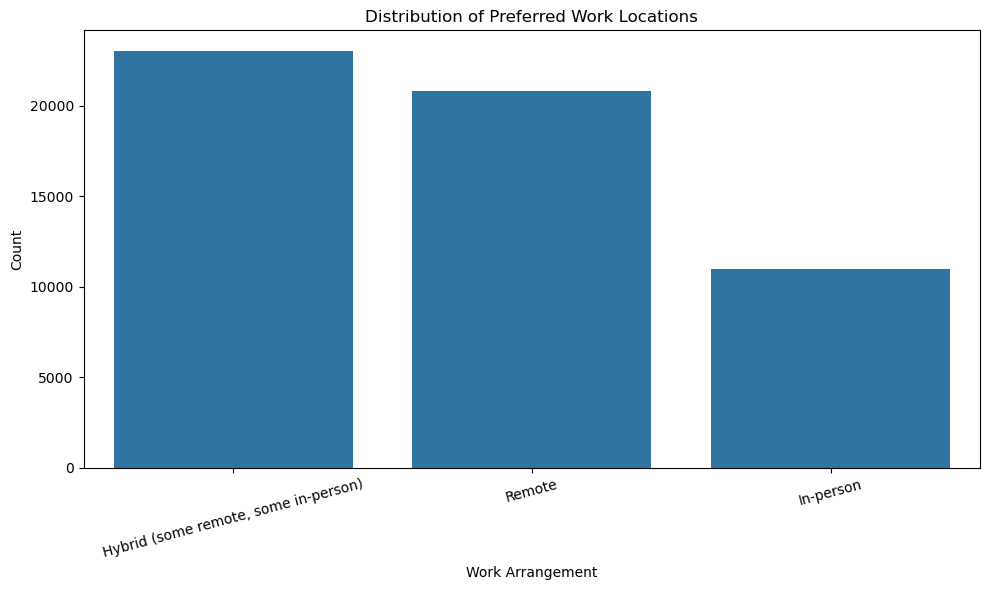

In [28]:
# Plot histogram/bar chart of RemoteWork preferences

plt.figure(figsize=(10,6))

sns.barplot(
    x=remote_counts.index,
    y=remote_counts.values
)

plt.title('Distribution of Preferred Work Locations')
plt.xlabel('Work Arrangement')
plt.ylabel('Count')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data

**4.1 Histogram of Median CompTotal for Ages 45 to 60**

Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.

In [29]:
# SQL query to fetch Age and CompTotal

query = """
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL
  AND Age IS NOT NULL
"""

comp_df = pd.read_sql_query(query, conn)

# Display first few rows
print(comp_df.head())

               Age  CompTotal
0  18-24 years old  2040000.0
1  25-34 years old    28000.0
2  35-44 years old    85000.0
3  35-44 years old    50000.0
4  25-34 years old   110000.0


In [30]:
# Convert Age groups into approximate numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

comp_df['Age_numeric'] = comp_df['Age'].map(age_mapping)

In [31]:
# Filter respondents aged between 45 and 60

filtered_df = comp_df[
    (comp_df['Age_numeric'] >= 45) &
    (comp_df['Age_numeric'] <= 60)
]

In [32]:
# Remove extreme compensation outliers

upper_limit = filtered_df['CompTotal'].quantile(0.99)

filtered_df = filtered_df[
    filtered_df['CompTotal'] <= upper_limit
]

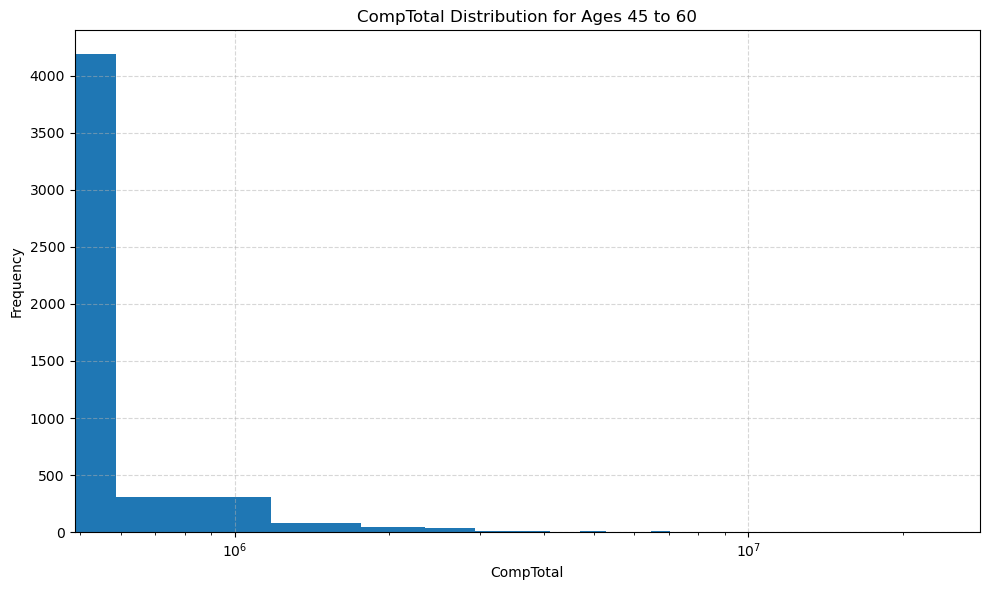

In [33]:
# Plot histogram of CompTotal for ages 45-60

plt.figure(figsize=(10,6))

plt.hist(
    filtered_df['CompTotal'],
    bins=40
)

plt.title('CompTotal Distribution for Ages 45 to 60')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')

plt.xscale('log')   # Better visibility for skewed compensation data

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**

Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.

In [34]:
# SQL query to fetch JobSat and YearsCodePro

query = """
SELECT YearsCodePro, JobSat
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSat IS NOT NULL
"""

jobsat_df = pd.read_sql_query(query, conn)

# Display first few rows
print(jobsat_df.head())

       YearsCodePro  JobSat
0                12     8.0
1                27     5.0
2                10    10.0
3  Less than 1 year     6.0
4                18     9.0


In [35]:
# Convert YearsCodePro and JobSat to numeric

jobsat_df['YearsCodePro'] = pd.to_numeric(
    jobsat_df['YearsCodePro'],
    errors='coerce'
)

jobsat_df['JobSat'] = pd.to_numeric(
    jobsat_df['JobSat'],
    errors='coerce'
)

# Remove missing values
jobsat_df = jobsat_df.dropna()

In [36]:
# Create experience groups

bins = [0, 5, 10, 20, 50]
labels = ['0-5', '5-10', '10-20', '20+']

jobsat_df['ExperienceGroup'] = pd.cut(
    jobsat_df['YearsCodePro'],
    bins=bins,
    labels=labels
)

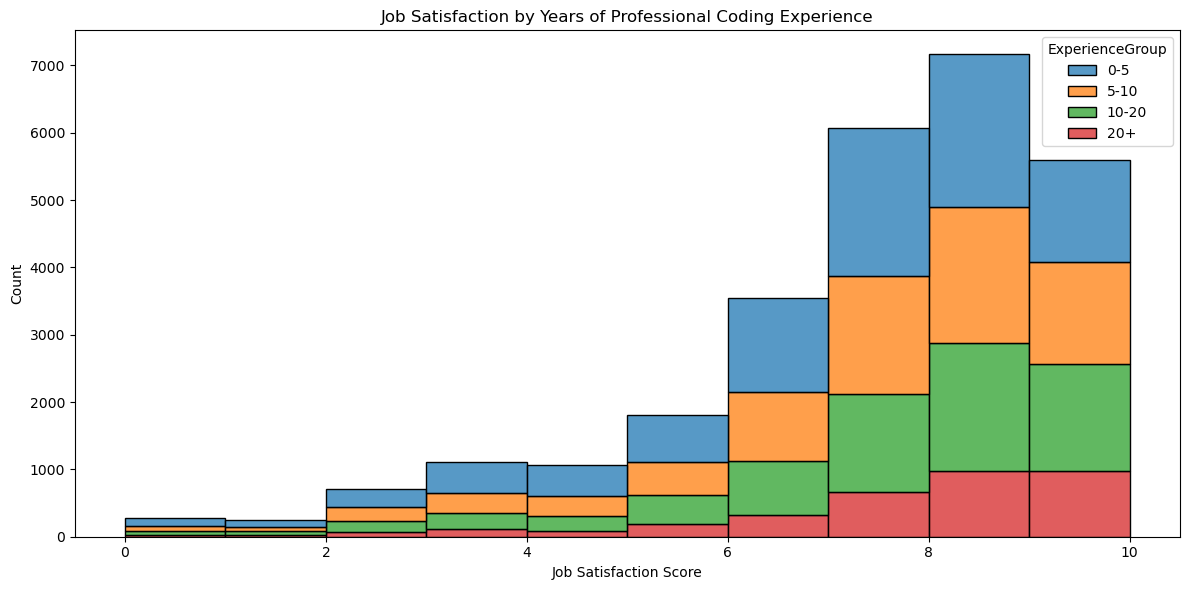

In [37]:
# Plot histogram of Job Satisfaction by experience group

plt.figure(figsize=(12,6))

sns.histplot(
    data=jobsat_df,
    x='JobSat',
    hue='ExperienceGroup',
    bins=10,
    multiple='stack'
)

plt.title('Job Satisfaction by Years of Professional Coding Experience')
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Final step: Close the database connection

Once you've completed the lab, make sure to close the connection to the SQLite database:

In [38]:
conn.close()

### Summary

In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.